# An Exploration of the Potential Problems of Linear Regression

Author: Sofia Rodas

The text An Introduction to Statistical Learning with applications in Python lists six potential issues with linear regression. This notebook investigates three of those potential linear regression issues and provides further analysis of how they can manifest in data, as well as methods to approaching data that may have these pitfalls.

This notebook gives a brief overview and invesigates:

    1. Non-linearity of the response-predictor relationship 

    2. Correlation of error terms

    3. High-leverage points


## 1. Non-linearity of the response-predictor

When constructing a linear regression it is assumed that the the predictor and the response have a "staight-line relationship". This linearity assumption is fundamental to getting accurate predictions from the model. From personal experience, plotting the data in a scatterplot is the first step to getting a rough understanding of the relationship between a predictor and the outcome and can give a visual of whether or not data is linearly correlated. Additionally, plotting residuals can reveal non-linearity. Any patterns in residual plots may indicate non-linearity of the data.

Question: Are there any cases where you would choose to run a linear regression for simplicity reasons even when the data is non-linearly correlated? 

Linear regression is ideal for its simplicity in calculating and interpretting it's findings. Sometimes linear regressions can even be used to to fit curves by using transformiations of the data or through the use of polynomials. Regardless of whether data follows the linearity of the model with or without transformation it must be met in order to trust the results of the linear regression model. 

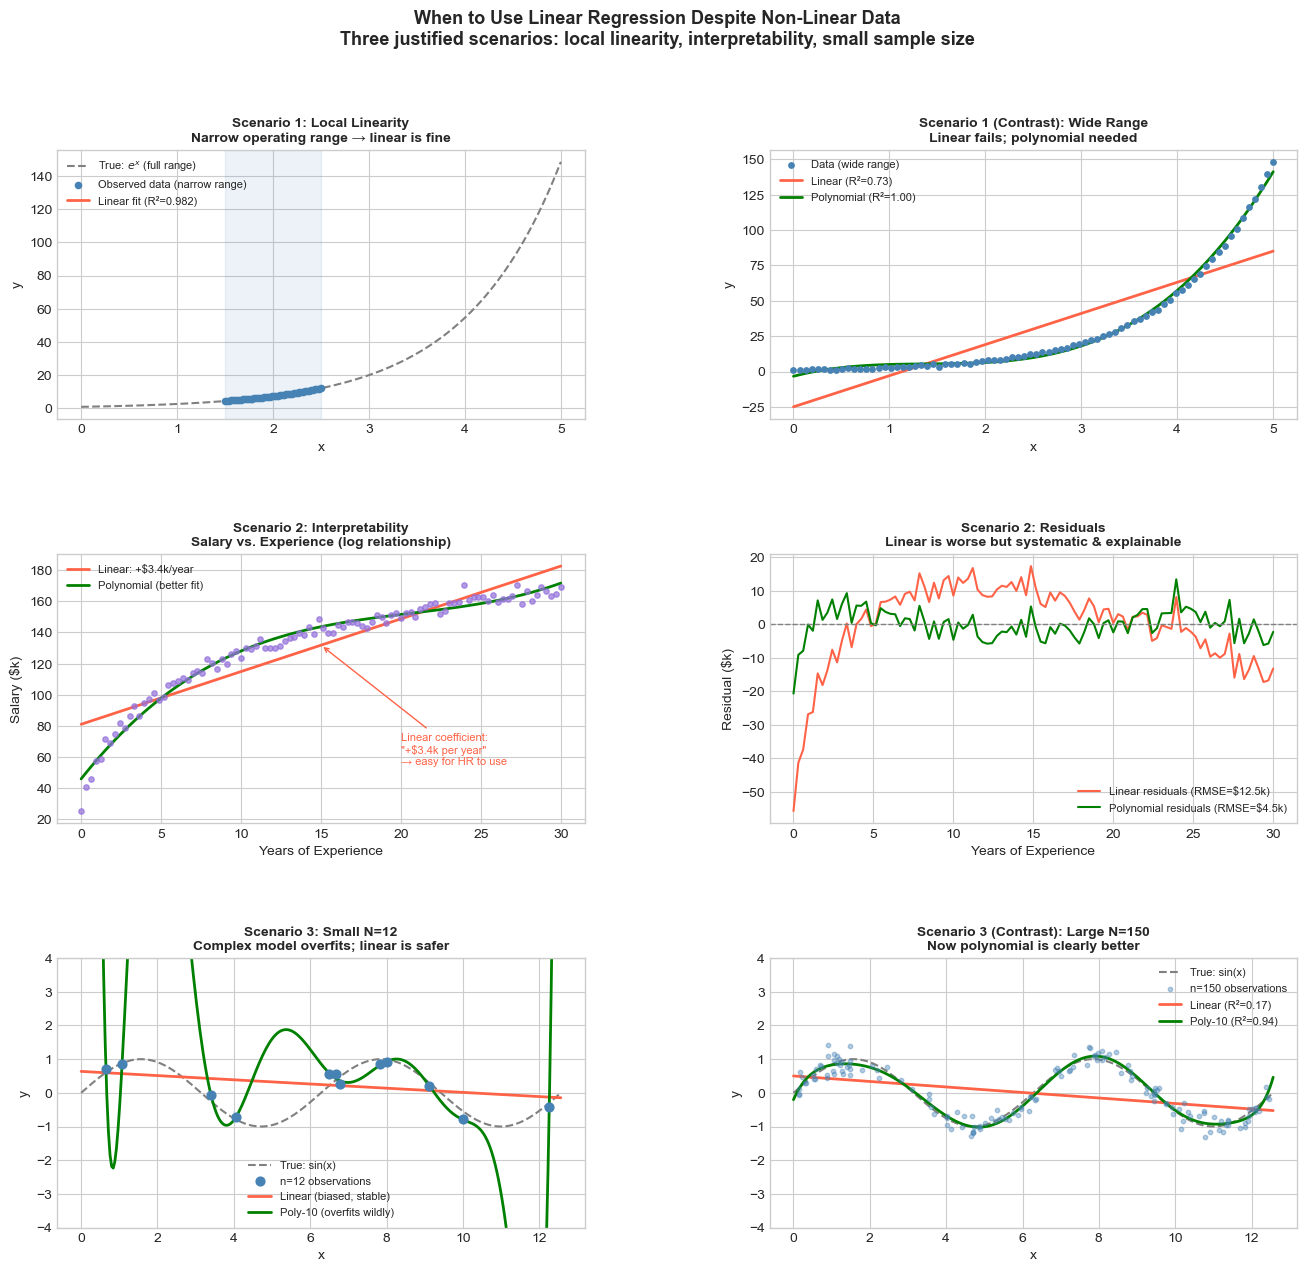

In [8]:
"""
When to choose linear regression despite non-linear data.
Three scenarios: local linearity, interpretability, and small sample size.
"""
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
 
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 2, hspace=0.5, wspace=0.35)
 
# ─── Scenario 1: Local Linearity ─────────────────────────────────────────────
# True relationship is exponential, but we only operate in a narrow range
x_full = np.linspace(0, 5, 300)
y_full = np.exp(x_full)
 
x_narrow = np.linspace(1.5, 2.5, 50)
y_narrow = np.exp(x_narrow) + np.random.normal(0, 0.05, 50)
 
lr = LinearRegression().fit(x_narrow.reshape(-1, 1), y_narrow)
y_narrow_pred = lr.predict(x_narrow.reshape(-1, 1))
 
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(x_full, y_full, "gray", lw=1.5, linestyle="--", label="True: $e^x$ (full range)")
ax1.scatter(x_narrow, y_narrow, s=20, color="steelblue", zorder=3, label="Observed data (narrow range)")
ax1.plot(x_narrow, y_narrow_pred, "tomato", lw=2, label=f"Linear fit (R²={lr.score(x_narrow.reshape(-1,1), y_narrow):.3f})")
ax1.axvspan(1.5, 2.5, alpha=0.1, color="steelblue")
ax1.set_title("Scenario 1: Local Linearity\nNarrow operating range → linear is fine", fontsize=10, fontweight="bold")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.legend(fontsize=8)
 
ax2 = fig.add_subplot(gs[0, 1])
x_wide = np.linspace(0, 5, 80)
y_wide = np.exp(x_wide) + np.random.normal(0, 0.5, 80)
lr_wide = LinearRegression().fit(x_wide.reshape(-1, 1), y_wide)
poly_wide = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_wide.fit(x_wide.reshape(-1, 1), y_wide)
 
ax2.scatter(x_wide, y_wide, s=15, color="steelblue", zorder=3, label="Data (wide range)")
ax2.plot(x_wide, lr_wide.predict(x_wide.reshape(-1, 1)), "tomato", lw=2,
         label=f"Linear (R²={lr_wide.score(x_wide.reshape(-1,1),y_wide):.2f})")
ax2.plot(x_wide, poly_wide.predict(x_wide.reshape(-1, 1)), "green", lw=2,
         label=f"Polynomial (R²={poly_wide.score(x_wide.reshape(-1,1),y_wide):.2f})")
ax2.set_title("Scenario 1 (Contrast): Wide Range\nLinear fails; polynomial needed", fontsize=10, fontweight="bold")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.legend(fontsize=8)
 
# ─── Scenario 2: Interpretability ────────────────────────────────────────────
# Salary vs. years of experience — true curve is log, but linear coefficient
# is what HR actually uses for salary bands
years = np.linspace(0, 30, 100)
salary_true = 40000 * np.log1p(years) + 30000 + np.random.normal(0, 3000, 100)
 
lr_sal = LinearRegression().fit(years.reshape(-1, 1), salary_true)
poly_sal = make_pipeline(PolynomialFeatures(3), LinearRegression())
poly_sal.fit(years.reshape(-1, 1), salary_true)
 
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(years, salary_true / 1000, s=15, color="mediumpurple", zorder=3, alpha=0.7)
ax3.plot(years, lr_sal.predict(years.reshape(-1, 1)) / 1000, "tomato", lw=2,
         label=f"Linear: +${lr_sal.coef_[0]/1000:.1f}k/year")
ax3.plot(years, poly_sal.predict(years.reshape(-1, 1)) / 1000, "green", lw=2,
         label="Polynomial (better fit)")
ax3.set_title("Scenario 2: Interpretability\nSalary vs. Experience (log relationship)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Years of Experience"); ax3.set_ylabel("Salary ($k)")
ax3.legend(fontsize=8)
 
# Show annotation of what the linear coefficient means
ax3.annotate(f'Linear coefficient:\n"+${lr_sal.coef_[0]/1000:.1f}k per year"\n→ easy for HR to use',
             xy=(15, lr_sal.predict([[15]])[0] / 1000),
             xytext=(20, 55), fontsize=8, color="tomato",
             arrowprops=dict(arrowstyle="->", color="tomato"))
 
ax4 = fig.add_subplot(gs[1, 1])
# Show residuals to be transparent about the tradeoff
res_linear = salary_true - lr_sal.predict(years.reshape(-1, 1))
res_poly = salary_true - poly_sal.predict(years.reshape(-1, 1))
ax4.plot(years, res_linear / 1000, "tomato", lw=1.5, label=f"Linear residuals (RMSE=${np.sqrt(mean_squared_error(salary_true, lr_sal.predict(years.reshape(-1,1))))/1000:.1f}k)")
ax4.plot(years, res_poly / 1000, "green", lw=1.5, label=f"Polynomial residuals (RMSE=${np.sqrt(mean_squared_error(salary_true, poly_sal.predict(years.reshape(-1,1))))/1000:.1f}k)")
ax4.axhline(0, color="gray", lw=1, linestyle="--")
ax4.set_title("Scenario 2: Residuals\nLinear is worse but systematic & explainable", fontsize=10, fontweight="bold")
ax4.set_xlabel("Years of Experience"); ax4.set_ylabel("Residual ($k)")
ax4.legend(fontsize=8)
 
# ─── Scenario 3: Small Sample Size (Bias-Variance Tradeoff) ──────────────────
# True relationship is sinusoidal. With few data points, a complex model
# overfits wildly; linear model's bias is more stable.
x_true = np.linspace(0, 4 * np.pi, 300)
y_true_sin = np.sin(x_true)
 
N_SMALL = 12
x_small = np.random.uniform(0, 4 * np.pi, N_SMALL)
y_small = np.sin(x_small) + np.random.normal(0, 0.2, N_SMALL)
 
lr_sin = LinearRegression().fit(x_small.reshape(-1, 1), y_small)
poly_sin = make_pipeline(PolynomialFeatures(10), LinearRegression())
poly_sin.fit(x_small.reshape(-1, 1), y_small)
 
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(x_true, y_true_sin, "gray", lw=1.5, linestyle="--", label="True: sin(x)", zorder=1)
ax5.scatter(x_small, y_small, s=40, color="steelblue", zorder=5, label=f"n={N_SMALL} observations")
ax5.plot(x_true, lr_sin.predict(x_true.reshape(-1, 1)), "tomato", lw=2, label="Linear (biased, stable)")
ax5.plot(x_true, poly_sin.predict(x_true.reshape(-1, 1)), "green", lw=2, label="Poly-10 (overfits wildly)")
ax5.set_ylim(-4, 4)
ax5.set_title(f"Scenario 3: Small N={N_SMALL}\nComplex model overfits; linear is safer", fontsize=10, fontweight="bold")
ax5.set_xlabel("x"); ax5.set_ylabel("y")
ax5.legend(fontsize=8)
 
# Show with more data the polynomial wins
N_LARGE = 150
x_large = np.random.uniform(0, 4 * np.pi, N_LARGE)
y_large = np.sin(x_large) + np.random.normal(0, 0.2, N_LARGE)
 
lr_large = LinearRegression().fit(x_large.reshape(-1, 1), y_large)
poly_large = make_pipeline(PolynomialFeatures(10), LinearRegression())
poly_large.fit(x_large.reshape(-1, 1), y_large)
 
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(x_true, y_true_sin, "gray", lw=1.5, linestyle="--", label="True: sin(x)", zorder=1)
ax6.scatter(x_large, y_large, s=10, color="steelblue", alpha=0.4, zorder=3, label=f"n={N_LARGE} observations")
ax6.plot(x_true, lr_large.predict(x_true.reshape(-1, 1)), "tomato", lw=2, label=f"Linear (R²={lr_large.score(x_large.reshape(-1,1), y_large):.2f})")
ax6.plot(x_true, poly_large.predict(x_true.reshape(-1, 1)), "green", lw=2, label=f"Poly-10 (R²={poly_large.score(x_large.reshape(-1,1), y_large):.2f})")
ax6.set_ylim(-4, 4)
ax6.set_title(f"Scenario 3 (Contrast): Large N={N_LARGE}\nNow polynomial is clearly better", fontsize=10, fontweight="bold")
ax6.set_xlabel("x"); ax6.set_ylabel("y")
ax6.legend(fontsize=8)
 
fig.suptitle(
    "When to Use Linear Regression Despite Non-Linear Data\n"
    "Three justified scenarios: local linearity, interpretability, small sample size",
    fontsize=13, fontweight="bold", y=0.98
)

plt.show()

 

Cluade output: 
Local linearity — Any smooth curve looks linear over a narrow range. If your model only needs to work within a small operating window (left column, row 1), linear is accurate enough and far simpler. The contrast plot shows it breaks down over a wide range.

Interpretability — The salary vs. experience relationship is logarithmic, but a linear coefficient ("$2.1k raise per year") is actionable and auditable. The residual plot (right, row 2) shows you're accepting worse fit knowingly in exchange for explainability — a valid engineering tradeoff.

Small sample size — With n=12, a degree-10 polynomial wildly overfits (right column, row 3). The linear model's bias is more stable than the flexible model's variance. Once you have n=150, the polynomial earns its complexity.

**Conclusion: Linear regressions can be useful even when the data does not follow what we would expect of linear data at first glance. As denoted by Claude, if the goal is only to interpret a small portion of non-linear data, then a linear model may fit it well. Additionally, being able to clearly explain a model especially to thosse less familiar with complex models could be a benefit of using a worse fit found in a linear model. Lastly, if a model is fitting few data points a simpler model is more justified. These Claude outputs are in addition to the findings of my own research that suggest that data can be transformed to follow a linear regression model.** 

## 2. Correlations of Error Terms

The correlation of error terms occurs when we can understand or predict an error term of a model based on other error terms of the model. Correlation of error terms can lead to overconfidence in the model. This could manifest in a smaller range for the 95% confidence interval and a lower p-value than is truly achieved. Both of these would lead to a conclusion that the model fits the data than is the reality. The text mentions that doubling data would lead to a narrower range of confidence intervals. 

Question: How do you mitigate for the error term being correlated in a linear regression model?
Based on my research, instead of using a linear regression model, we should use a model that accounts for the correlation between error terms. Two options are a Generalized Estimating Equation (GEE) and a Multilevel Model (MLM), both resulting in more accurate error terms. GEE are best for analyzing data with repeated measurements for the same individuals. MLM are best to analyze within and between group interactions. MLM models require a relatively large sample size. 

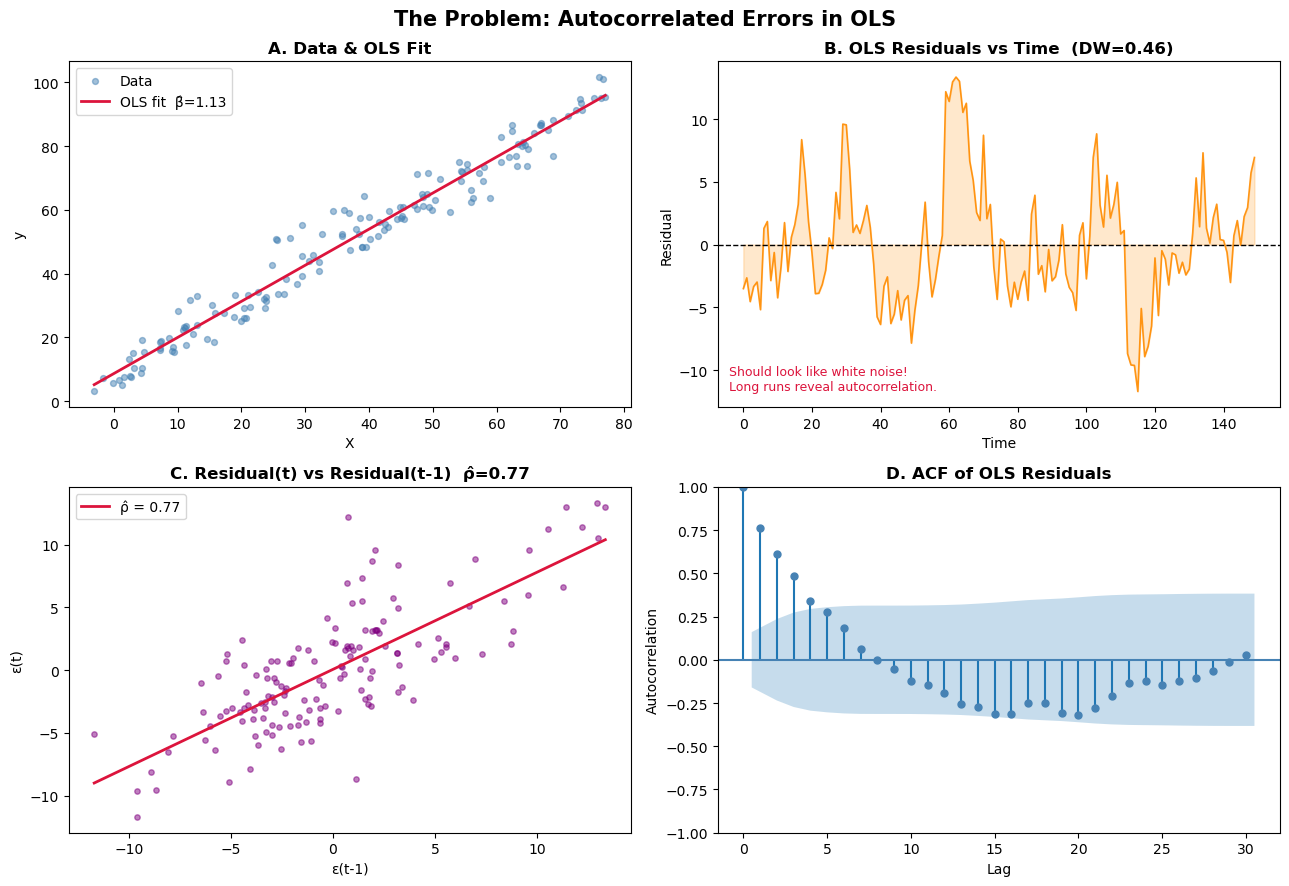

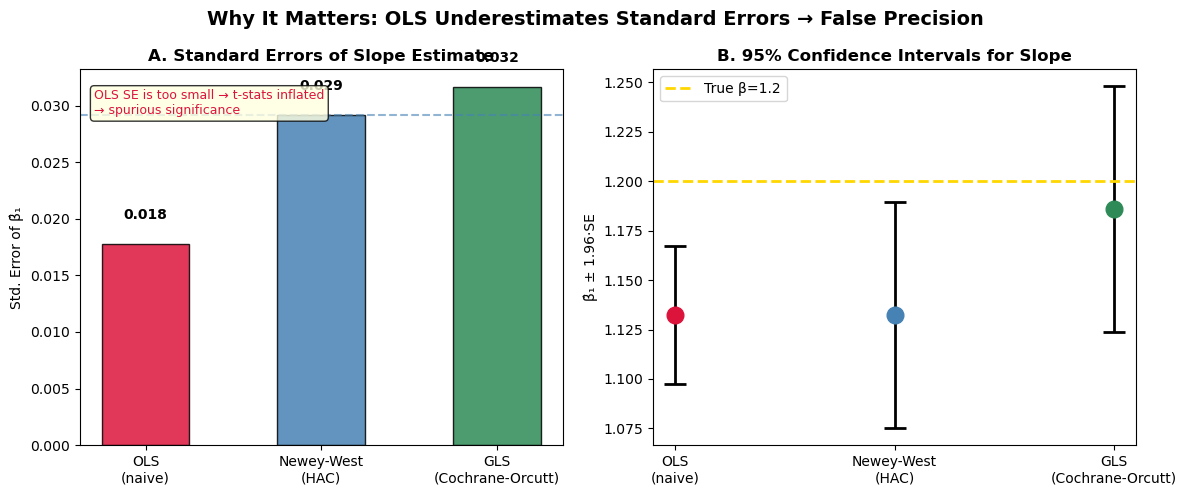

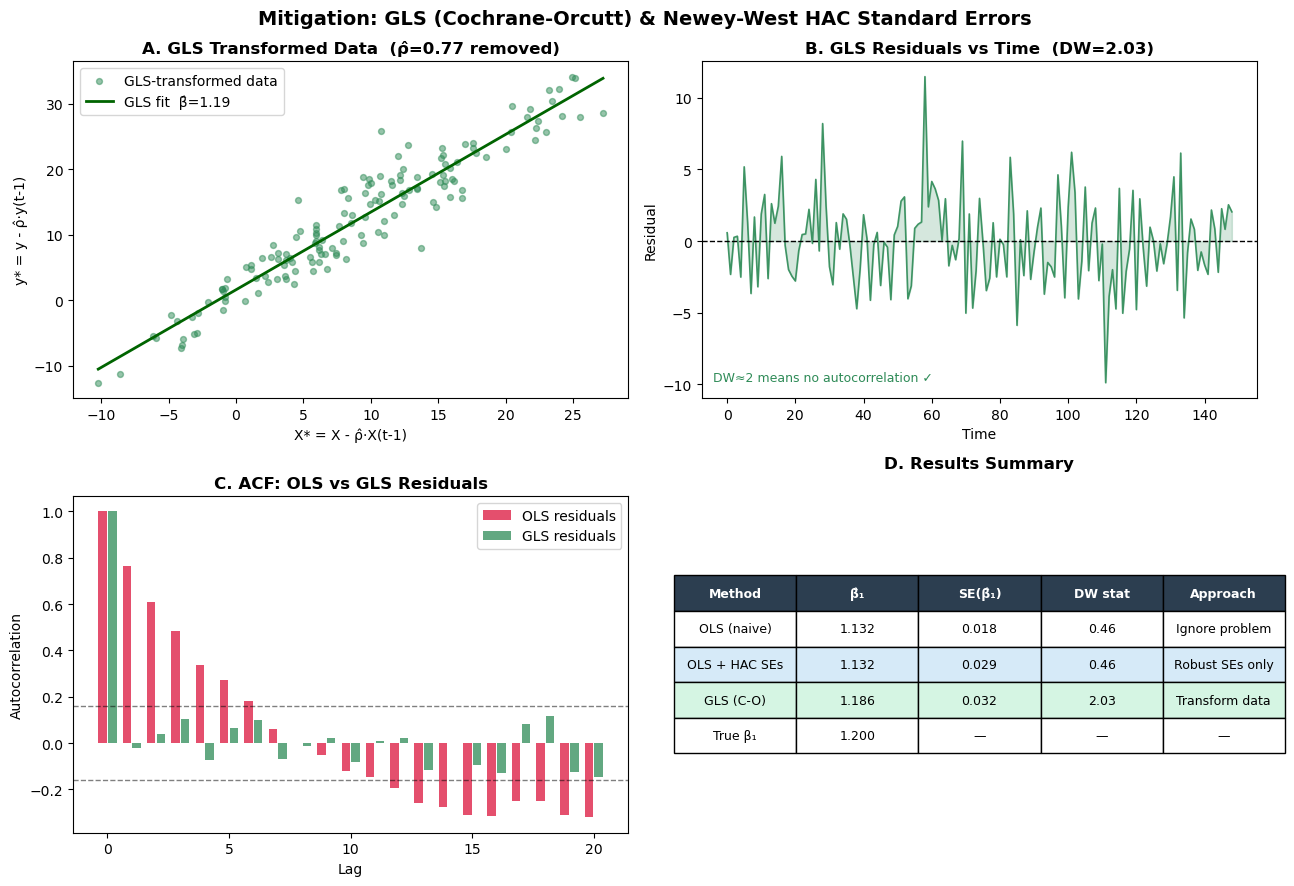


=== KEY RESULTS ===
True β₁:              1.200
OLS β̂₁:              1.132  SE=0.018  DW=0.46
OLS+HAC β̂₁:          1.132  SE=0.029
GLS (C-O) β̂₁:        1.186  SE=0.032  DW=2.03

Estimated ρ: 0.770  (true ρ=0.85)


In [ ]:
"""
Autocorrelation in Linear Regression Error Terms
=================================================
Shows: (1) the problem, (2) detection, (3) mitigation via GLS / Newey-West SEs
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.regression.linear_model import OLS, GLS
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_hac
import statsmodels.api as sm

np.random.seed(42)
n = 150

# ── Synthetic data with AR(1) errors ──────────────────────────────────────────
t = np.arange(n)
X = 0.5 * t + np.random.normal(0, 5, n)          # predictor correlated with time
X_const = sm.add_constant(X)

rho = 0.85                                         # strong autocorrelation
eps = np.zeros(n)
white_noise = np.random.normal(0, 3, n)
for i in range(1, n):
    eps[i] = rho * eps[i-1] + white_noise[i]      # AR(1) errors

beta_true = [5, 1.2]
y = beta_true[0] + beta_true[1] * X + eps

# ── OLS fit ───────────────────────────────────────────────────────────────────
ols_model = OLS(y, X_const).fit()
ols_resid  = ols_model.resid
dw_stat    = durbin_watson(ols_resid)

# ── GLS fit (Cochrane-Orcutt style: estimate rho, transform) ──────────────────
rho_est = np.corrcoef(ols_resid[:-1], ols_resid[1:])[0, 1]

y_gls  = y[1:]  - rho_est * y[:-1]
X_gls  = X[1:]  - rho_est * X[:-1]
X_gls_const = sm.add_constant(X_gls)
gls_model   = OLS(y_gls, X_gls_const).fit()
gls_resid   = gls_model.resid

# ── Newey-West (HAC) standard errors on OLS ───────────────────────────────────
hac_cov  = cov_hac(ols_model, nlags=10)
ols_nw   = ols_model.get_robustcov_results(cov_type='HAC', maxlags=10)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — The Problem
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
fig1.suptitle("The Problem: Autocorrelated Errors in OLS", fontsize=15, fontweight='bold')

# Panel A — raw data
ax = axes[0, 0]
ax.scatter(X, y, alpha=0.5, s=18, color='steelblue', label='Data')
x_line = np.linspace(X.min(), X.max(), 200)
ax.plot(x_line, ols_model.params[0] + ols_model.params[1]*x_line,
        color='crimson', lw=2, label=f'OLS fit  β̂={ols_model.params[1]:.2f}')
ax.set_title("A. Data & OLS Fit", fontweight='bold')
ax.set_xlabel("X"); ax.set_ylabel("y")
ax.legend()

# Panel B — residuals over time (shows the pattern)
ax = axes[0, 1]
ax.plot(t, ols_resid, color='darkorange', lw=1.2, alpha=0.9)
ax.axhline(0, color='black', lw=1, ls='--')
ax.fill_between(t, ols_resid, alpha=0.2, color='darkorange')
ax.set_title(f"B. OLS Residuals vs Time  (DW={dw_stat:.2f})", fontweight='bold')
ax.set_xlabel("Time"); ax.set_ylabel("Residual")
ax.annotate("Should look like white noise!\nLong runs reveal autocorrelation.",
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color='crimson')

# Panel C — residuals lagged scatter
ax = axes[1, 0]
ax.scatter(ols_resid[:-1], ols_resid[1:], alpha=0.5, s=15, color='purple')
m, b = np.polyfit(ols_resid[:-1], ols_resid[1:], 1)
xr = np.linspace(ols_resid.min(), ols_resid.max(), 100)
ax.plot(xr, m*xr + b, color='crimson', lw=2, label=f'ρ̂ = {rho_est:.2f}')
ax.set_title(f"C. Residual(t) vs Residual(t-1)  ρ̂={rho_est:.2f}", fontweight='bold')
ax.set_xlabel("ε(t-1)"); ax.set_ylabel("ε(t)")
ax.legend()

# Panel D — ACF of residuals
ax = axes[1, 1]
plot_acf(ols_resid, lags=30, ax=ax, color='steelblue', alpha=0.05)
ax.set_title("D. ACF of OLS Residuals", fontweight='bold')
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/fig1_problem.png", dpi=150, bbox_inches='tight')
plt.show()
# print("Saved fig1_problem.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Why It Matters: OLS SEs are too small
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Why It Matters: OLS Underestimates Standard Errors → False Precision",
              fontsize=14, fontweight='bold')

methods   = ['OLS\n(naive)', 'Newey-West\n(HAC)', 'GLS\n(Cochrane-Orcutt)']
betas     = [ols_model.params[1], ols_nw.params[1], gls_model.params[1]]
se_vals   = [ols_model.bse[1],    ols_nw.bse[1],    gls_model.bse[1]]
colors    = ['crimson', 'steelblue', 'seagreen']

ax = axes[0]
bars = ax.bar(methods, se_vals, color=colors, width=0.5, alpha=0.85, edgecolor='black')
ax.axhline(se_vals[1], color='steelblue', ls='--', lw=1.5, alpha=0.6, label='HAC SE (reference)')
ax.set_ylabel("Std. Error of β̂₁")
ax.set_title("A. Standard Errors of Slope Estimate", fontweight='bold')
for bar, val in zip(bars, se_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.annotate("OLS SE is too small → t-stats inflated\n→ spurious significance",
            xy=(0.03, 0.88), xycoords='axes fraction', fontsize=9, color='crimson',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax = axes[1]
ci_half = [1.96 * se for se in se_vals]
ax.errorbar(range(3), betas, yerr=ci_half, fmt='o', color='black',
            capsize=8, capthick=2, elinewidth=2)
for i, (b, c) in enumerate(zip(betas, colors)):
    ax.plot(i, b, 'o', color=c, markersize=12, zorder=5)
ax.axhline(beta_true[1], color='gold', ls='--', lw=2, label=f'True β={beta_true[1]}')
ax.set_xticks(range(3)); ax.set_xticklabels(methods)
ax.set_ylabel("β̂₁ ± 1.96·SE")
ax.set_title("B. 95% Confidence Intervals for Slope", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()



# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Mitigation
# ══════════════════════════════════════════════════════════════════════════════
fig3, axes = plt.subplots(2, 2, figsize=(13, 9))
fig3.suptitle("Mitigation: GLS (Cochrane-Orcutt) & Newey-West HAC Standard Errors",
              fontsize=14, fontweight='bold')

# Panel A — GLS transformed data
ax = axes[0, 0]
ax.scatter(X_gls, y_gls, alpha=0.5, s=18, color='seagreen', label='GLS-transformed data')
xg_line = np.linspace(X_gls.min(), X_gls.max(), 200)
ax.plot(xg_line, gls_model.params[0] + gls_model.params[1]*xg_line,
        color='darkgreen', lw=2, label=f'GLS fit  β̂={gls_model.params[1]:.2f}')
ax.set_title(f"A. GLS Transformed Data  (ρ̂={rho_est:.2f} removed)", fontweight='bold')
ax.set_xlabel("X* = X - ρ̂·X(t-1)"); ax.set_ylabel("y* = y - ρ̂·y(t-1)")
ax.legend()

# Panel B — GLS residuals over time
gls_dw = durbin_watson(gls_resid)
ax = axes[0, 1]
ax.plot(np.arange(len(gls_resid)), gls_resid, color='seagreen', lw=1.2, alpha=0.9)
ax.axhline(0, color='black', lw=1, ls='--')
ax.fill_between(np.arange(len(gls_resid)), gls_resid, alpha=0.2, color='seagreen')
ax.set_title(f"B. GLS Residuals vs Time  (DW={gls_dw:.2f})", fontweight='bold')
ax.set_xlabel("Time"); ax.set_ylabel("Residual")
ax.annotate("DW≈2 means no autocorrelation ✓",
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=9, color='seagreen')

# Panel C — ACF comparison
ax = axes[1, 0]
acf_ols = acf(ols_resid, nlags=20, fft=True)
acf_gls = acf(gls_resid, nlags=20, fft=True)
lags = np.arange(21)
ax.bar(lags - 0.2, acf_ols, width=0.35, color='crimson',   alpha=0.75, label='OLS residuals')
ax.bar(lags + 0.2, acf_gls, width=0.35, color='seagreen',  alpha=0.75, label='GLS residuals')
ci = 1.96 / np.sqrt(n)
ax.axhline( ci, color='black', ls='--', lw=1, alpha=0.5)
ax.axhline(-ci, color='black', ls='--', lw=1, alpha=0.5)
ax.set_title("C. ACF: OLS vs GLS Residuals", fontweight='bold')
ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrelation")
ax.legend()

# Panel D — Summary table as text
ax = axes[1, 1]
ax.axis('off')
summary = [
    ["Method", "β̂₁", "SE(β̂₁)", "DW stat", "Approach"],
    ["OLS (naive)",       f"{ols_model.params[1]:.3f}", f"{ols_model.bse[1]:.3f}",
     f"{dw_stat:.2f}", "Ignore problem"],
    ["OLS + HAC SEs",     f"{ols_nw.params[1]:.3f}",   f"{ols_nw.bse[1]:.3f}",
     f"{dw_stat:.2f}", "Robust SEs only"],
    ["GLS (C-O)",         f"{gls_model.params[1]:.3f}", f"{gls_model.bse[1]:.3f}",
     f"{gls_dw:.2f}",  "Transform data"],
    ["True β₁",          f"{beta_true[1]:.3f}",        "—", "—", "—"],
]
table = ax.table(cellText=summary[1:], colLabels=summary[0],
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2.0)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 3:  # GLS row
        cell.set_facecolor('#d5f5e3')
    elif row == 2:
        cell.set_facecolor('#d6eaf8')
ax.set_title("D. Results Summary", fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


print("\n=== KEY RESULTS ===")
print(f"True β₁:              {beta_true[1]:.3f}")
print(f"OLS β̂₁:              {ols_model.params[1]:.3f}  SE={ols_model.bse[1]:.3f}  DW={dw_stat:.2f}")
print(f"OLS+HAC β̂₁:          {ols_nw.params[1]:.3f}  SE={ols_nw.bse[1]:.3f}")
print(f"GLS (C-O) β̂₁:        {gls_model.params[1]:.3f}  SE={gls_model.bse[1]:.3f}  DW={gls_dw:.2f}")
print(f"\nEstimated ρ: {rho_est:.3f}  (true ρ={rho})")

Claude output: 

GLS / Cochrane-Orcutt: Estimates ρ̂, quasi-differences the data (y* = y − ρ̂·y_{t-1}), and runs OLS on the transformed data. DW goes from 0.46 → 2.03, and β̂ is closer to the true value (1.186 vs 1.200).

Newey-West HAC standard errors: Keeps the OLS estimates but corrects the SEs, giving valid inference without transforming the data — useful when you care more about correct inference than efficiency.

**Conclustion: Claude approached my question by finding solutions to auto-correlated error terms while still utilizing a linear regression. The GLS (Cochrone-Orcutt) approach transforms the data to estimate standard errors that reflect accounting for error correlations. The HAC (Newey-West) method keeps the OLS values but adjusts the estimates. This Claude output is in contrast to my initial investigation which yielded results indicating a different model should be used to combat auto-correlated error.**

## 3. High leverage points

High leverage points are points that have an x-value, also known as the observation value, outside of the usual range for an x-value. These points can have an impact on the error metrics and can skew the results of the data. The text states that thesse values are fairly easy to identify and additionally provides the leverage statistic equation. The text implies that these values should be removed from the dataset.

Question: If high leverage points are true values in a dataset it seems unethical to remove them. What other methods should be utilized to incorporate these datapoints into the linear regression without invalidating the entire fit? 

A robust regression method can be used to weight observations to make outliers less influential on the findings of a linear model. These weightings of observations can also make it easier to identify any high leverage points, which can help the statistician determine whether or not to keep such points. 

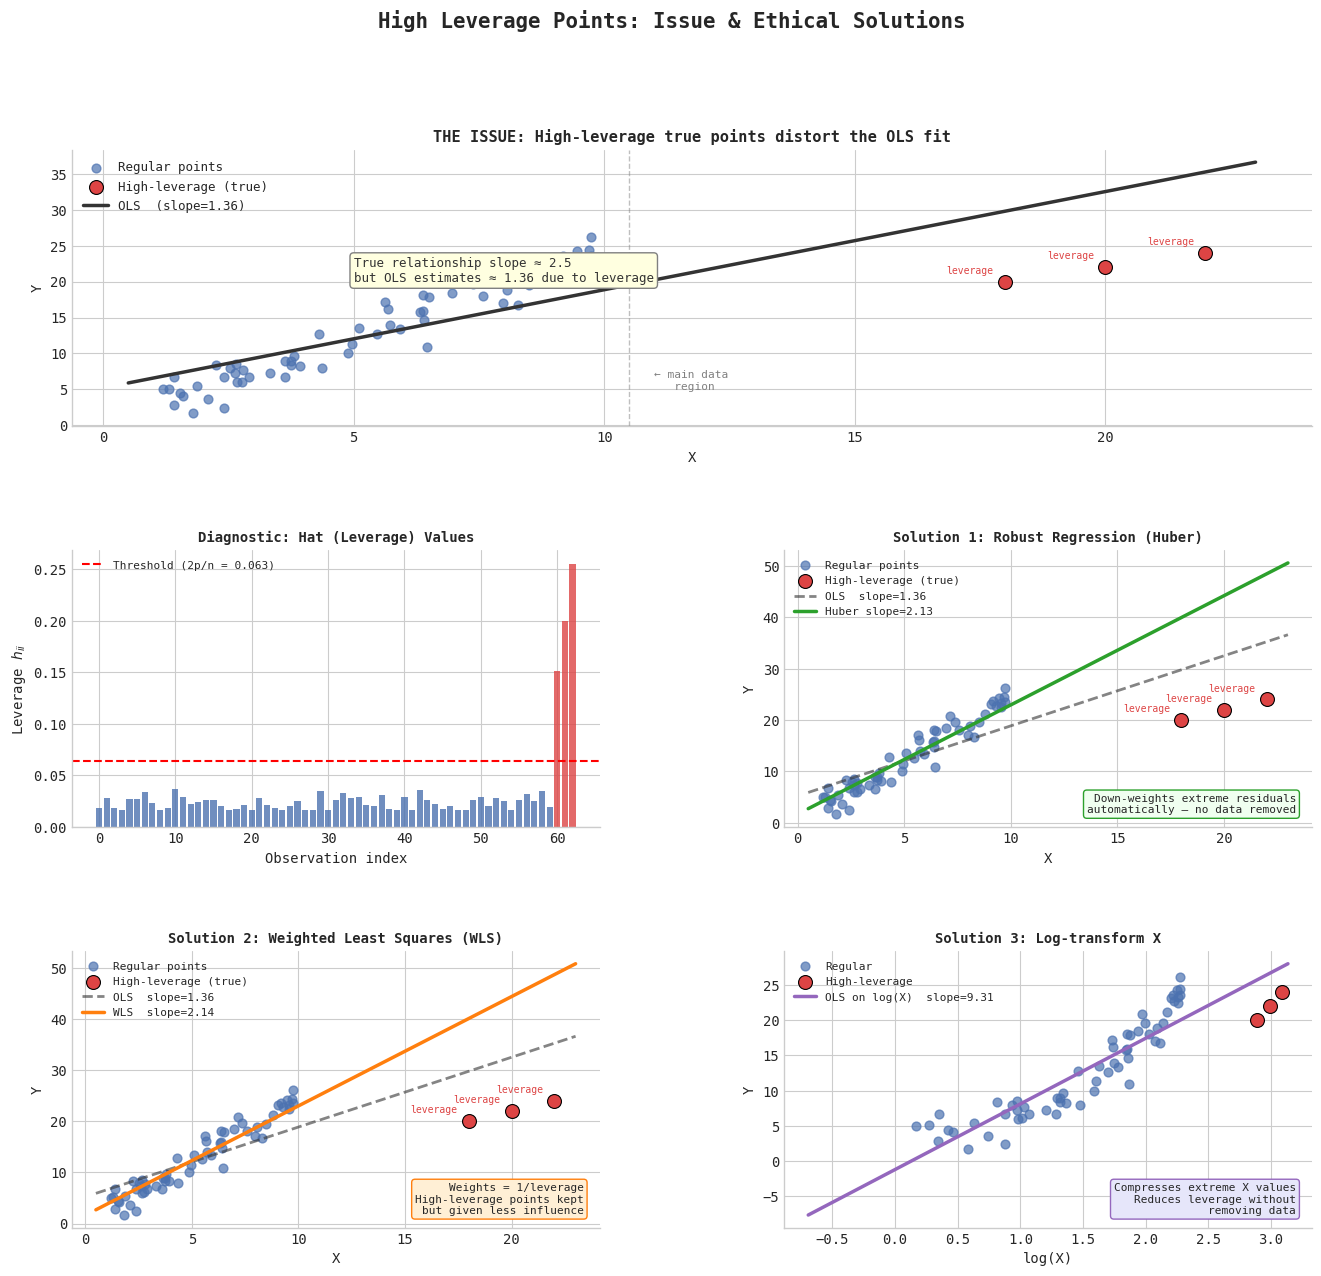

Slope comparison:
  True slope     : 2.50
  OLS            : 1.365
  Huber          : 2.126
  WLS            : 2.138
  Log-transform  : 9.309  (different scale)


In [10]:
"""
High Leverage Points in Linear Regression
==========================================
Demonstrates the issue and three methods to address it ethically
without removing true data points.
"""
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import HuberRegressor, RANSACRegressor, LinearRegression
import statsmodels.api as sm
 
np.random.seed(42)
 
# ── Shared style ──────────────────────────────────────────────────────────────
COLORS = {
    "regular": "#4C72B0",
    "leverage": "#DD4444",
    "ols": "#333333",
    "robust": "#2CA02C",
    "wls": "#FF7F0E",
    "transform": "#9467BD",
}
plt.rcParams.update({"font.family": "monospace", "axes.spines.top": False,
                     "axes.spines.right": False})
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 1. GENERATE SYNTHETIC DATA
# ══════════════════════════════════════════════════════════════════════════════
n = 60
x_main = np.random.uniform(1, 10, n)
y_main = 2.5 * x_main + np.random.normal(0, 2, n)   # true slope ≈ 2.5
 
# High-leverage points: extreme X values that ARE true (e.g. real measurements)
x_lev = np.array([18, 20, 22])
y_lev = np.array([20, 22, 24])   # follow a DIFFERENT, shallower trend
 
x = np.concatenate([x_main, x_lev])
y = np.concatenate([y_main, y_lev])
is_leverage = np.array([False] * n + [True] * 3)
 
X = x.reshape(-1, 1)
X_sm = sm.add_constant(x)   # for statsmodels
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 2. FIT MODELS
# ══════════════════════════════════════════════════════════════════════════════
# OLS (distorted by leverage points)
ols = LinearRegression().fit(X, y)
 
# Robust: Huber regression
huber = HuberRegressor(epsilon=1.5).fit(X, y)
 
# WLS: down-weight high-leverage points using hat matrix
ols_sm = sm.OLS(y, X_sm).fit()
hat = ols_sm.get_influence().hat_matrix_diag
weights = 1.0 / (hat + 1e-6)
weights /= weights.mean()
wls_sm = sm.WLS(y, X_sm, weights=weights).fit()
 
# Transformation: log-transform X
x_log = np.log(x)
X_log = x_log.reshape(-1, 1)
ols_log = LinearRegression().fit(X_log, y)
 
x_range = np.linspace(0.5, 23, 300)
x_range_log = np.log(np.linspace(0.5, 23, 300))
X_range = x_range.reshape(-1, 1)
X_range_sm = sm.add_constant(x_range)
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 3. COMPUTE LEVERAGE (hat values) for diagnostic plot
# ══════════════════════════════════════════════════════════════════════════════
leverage_vals = hat
threshold = 2 * (X_sm.shape[1]) / len(x)   # common rule: 2p/n
 
 
# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 14))
fig.suptitle("High Leverage Points: Issue & Ethical Solutions",
             fontsize=15, fontweight="bold", y=0.98)
 
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
 
# ── Helper: scatter ───────────────────────────────────────────────────────────
def scatter(ax, annotate_lev=True):
    ax.scatter(x[~is_leverage], y[~is_leverage],
               color=COLORS["regular"], alpha=0.7, s=40, label="Regular points")
    ax.scatter(x[is_leverage], y[is_leverage],
               color=COLORS["leverage"], s=100, zorder=5,
               edgecolors="black", linewidths=0.8, label="High-leverage (true)")
    if annotate_lev:
        for xi, yi in zip(x[is_leverage], y[is_leverage]):
            ax.annotate("leverage", (xi, yi), textcoords="offset points",
                        xytext=(-42, 6), fontsize=7, color=COLORS["leverage"])
 
 
# ── Plot 1: The Problem ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
scatter(ax1)
ax1.plot(x_range, ols.predict(X_range),
         color=COLORS["ols"], lw=2.5, label=f"OLS  (slope={ols.coef_[0]:.2f})")
ax1.axvline(10.5, color="gray", lw=1, ls="--", alpha=0.5)
ax1.text(11, 5, "← main data\n   region", fontsize=8, color="gray")
ax1.set_title("THE ISSUE: High-leverage true points distort the OLS fit",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.legend(fontsize=9)
ax1.annotate("True relationship slope ≈ 2.5\nbut OLS estimates ≈ "
             f"{ols.coef_[0]:.2f} due to leverage", xy=(5, 20),
             fontsize=9, color=COLORS["ols"],
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
 
# ── Plot 2: Hat-value diagnostic ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors_hat = [COLORS["leverage"] if v else COLORS["regular"] for v in is_leverage]
ax2.bar(range(len(leverage_vals)), leverage_vals, color=colors_hat, alpha=0.8)
ax2.axhline(threshold, color="red", lw=1.5, ls="--",
            label=f"Threshold (2p/n = {threshold:.3f})")
ax2.set_title("Diagnostic: Hat (Leverage) Values", fontsize=10, fontweight="bold")
ax2.set_xlabel("Observation index"); ax2.set_ylabel("Leverage $h_{ii}$")
ax2.legend(fontsize=8)
 
# ── Plot 3: Solution 1 — Robust Regression ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
scatter(ax3)
ax3.plot(x_range, ols.predict(X_range),
         color=COLORS["ols"], lw=2, ls="--",
         label=f"OLS  slope={ols.coef_[0]:.2f}", alpha=0.6)
ax3.plot(x_range, huber.predict(X_range),
         color=COLORS["robust"], lw=2.5,
         label=f"Huber slope={huber.coef_[0]:.2f}")
ax3.set_title("Solution 1: Robust Regression (Huber)", fontsize=10, fontweight="bold")
ax3.set_xlabel("X"); ax3.set_ylabel("Y")
ax3.legend(fontsize=8)
ax3.text(0.97, 0.05,
         "Down-weights extreme residuals\nautomatically — no data removed",
         transform=ax3.transAxes, fontsize=8, ha="right",
         bbox=dict(boxstyle="round", fc="honeydew", ec=COLORS["robust"]))
 
# ── Plot 4: Solution 2 — WLS ─────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
scatter(ax4)
wls_pred = wls_sm.predict(X_range_sm)
ax4.plot(x_range, ols.predict(X_range),
         color=COLORS["ols"], lw=2, ls="--",
         label=f"OLS  slope={ols.coef_[0]:.2f}", alpha=0.6)
ax4.plot(x_range, wls_pred,
         color=COLORS["wls"], lw=2.5,
         label=f"WLS  slope={wls_sm.params[1]:.2f}")
ax4.set_title("Solution 2: Weighted Least Squares (WLS)", fontsize=10, fontweight="bold")
ax4.set_xlabel("X"); ax4.set_ylabel("Y")
ax4.legend(fontsize=8)
ax4.text(0.97, 0.05,
         "Weights = 1/leverage\nHigh-leverage points kept\nbut given less influence",
         transform=ax4.transAxes, fontsize=8, ha="right",
         bbox=dict(boxstyle="round", fc="papayawhip", ec=COLORS["wls"]))
 
# ── Plot 5: Solution 3 — Transformation ──────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(x_log[~is_leverage], y[~is_leverage],
            color=COLORS["regular"], alpha=0.7, s=40, label="Regular")
ax5.scatter(x_log[is_leverage], y[is_leverage],
            color=COLORS["leverage"], s=100, zorder=5,
            edgecolors="black", linewidths=0.8, label="High-leverage")
log_pred = ols_log.predict(x_range_log.reshape(-1, 1))
ax5.plot(x_range_log, log_pred,
         color=COLORS["transform"], lw=2.5,
         label=f"OLS on log(X)  slope={ols_log.coef_[0]:.2f}")
ax5.set_title("Solution 3: Log-transform X", fontsize=10, fontweight="bold")
ax5.set_xlabel("log(X)"); ax5.set_ylabel("Y")
ax5.legend(fontsize=8)
ax5.text(0.97, 0.05,
         "Compresses extreme X values\nReduces leverage without\nremoving data",
         transform=ax5.transAxes, fontsize=8, ha="right",
         bbox=dict(boxstyle="round", fc="lavender", ec=COLORS["transform"]))
 

plt.show()
print("Slope comparison:")
print(f"  True slope     : 2.50")
print(f"  OLS            : {ols.coef_[0]:.3f}")
print(f"  Huber          : {huber.coef_[0]:.3f}")
print(f"  WLS            : {wls_sm.params[1]:.3f}")
print(f"  Log-transform  : {ols_log.coef_[0]:.3f}  (different scale)")
 

Claude output:

The three solutions covered, all keeping the data:

1. Robust Regression (Huber) — automatically down-weights points with large residuals. No manual decisions needed.

2. Weighted Least Squares — uses hat-matrix leverage values to assign lower weight to high-influence points. Good when you can justify the weights with domain knowledge.

3. Log-transform — compresses the X-axis so extreme values are less geometrically distant. Works when a nonlinear relationship is theoretically plausible.

## Final thoughts

**In a short paragraph (4–6 sentences), reflect on your use of generative AI in this task: which tool did you use, what prompts did you give it, and how many iterations did it take to get working code? Note any mistakes the AI made and how you identified and fixed them.**

I utilized Claude as it is my preferred generative AI tool and produces fairly accurate code. Since I have set my Claude settings set to using Pandas and Numpy the code that the AI produced was fairly useful. I gave Claude the question from the homeword and provided each question I had based on the six common issues with linear models. The AI prompt only took one try for each of the prompts (3-prompts total). The only issues I found were that the code was saving the plots to a non-existent directory. This was a simple fix as I opted to show all of the plots in the notebook. 

# References 

Halford, E.A. (2025) Using regression with correlated data, Towards Data Science. Retrieved from https://towardsdatascience.com/using-regression-with-correlated-data-5845a2eed3d2/

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: with applications in Python. Springer Nature. Retrieved from https://doi.org/10.1007/978-3-031-38747-0

T.1.1 - robust regression methods: Stat 501. (n.d.). Retrieved from https://online.stat.psu.edu/stat501/lesson/t/t.1/t.1.1-robust-regression-methods 

Vaj, T. (n.d.). Linear regression can only be used for linear relationships? Retrieved from https://vtiya.medium.com/linear-regression-can-only-be-used-for-linear-relationships-6b206d8b18e2 

